In this notebook, I performed different techniques of feature selection on a [Netflix User Dataset](https://www.kaggle.com/datasets/rhythmghai/netflix-user-watching-behavior-dataset) found on Kaggle.

## Imports

In [85]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [86]:
# for data processing and manipulation
import pandas as pd
import numpy as np

# scikit-learn modules for feature selection and model evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectKBest, SelectFromModel, chi2, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# libraries for visualization
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

## Load the dataset

Dataset is available under the data folder

In [87]:
# Load the dataset
df = pd.read_csv('./data/netflix_user_behavior_dataset.csv')

# Print datatypes
print(df.dtypes)

# Describe columns
df.describe(include='all')

user_id                       object
age                            int64
gender                        object
country                       object
account_age_months             int64
subscription_type             object
monthly_fee                  float64
payment_method                object
primary_device                object
devices_used                   int64
favorite_genre                object
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                       object
dtype: object


,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
count,50000,50000.000000,50000,50000,50000.000000,50000,50000.000000,50000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000
unique,50000,NaN,3,10,NaN,3,NaN,4,4,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,U100000,NaN,Female,Brazil,NaN,Standard,NaN,PayPal,Mobile,NaN,Documentary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,1,NaN,16759,5116,NaN,19931,NaN,12539,12585,NaN,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40036
mean,NaN,40.979240,NaN,NaN,29.874000,NaN,12.323340,NaN,NaN,1.999140,NaN,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520,NaN
std,NaN,13.528733,NaN,NaN,17.051104,NaN,3.309109,NaN,NaN,0.818238,NaN,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414,NaN
min,NaN,18.000000,NaN,NaN,1.000000,NaN,7.990000,NaN,NaN,1.000000,NaN,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,29.000000,NaN,NaN,15.000000,NaN,7.990000,NaN,NaN,1.000000,NaN,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000,NaN
50%,NaN,41.000000,NaN,NaN,30.000000,NaN,12.990000,NaN,NaN,2.000000,NaN,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000,NaN
75%,NaN,53.000000,NaN,NaN,45.000000,NaN,15.990000,NaN,NaN,3.000000,NaN,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000,NaN


In [88]:
# Preview the dataset
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


## Data Exploration

Since this is a synthetically generated dataset, we will have to explore from the ground up what it looks like.

In [89]:
# Check if there are null values in any of the columns. 
# In a synthetic dataset, it is not uncommon to see no null values anywhere.
df.isna().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

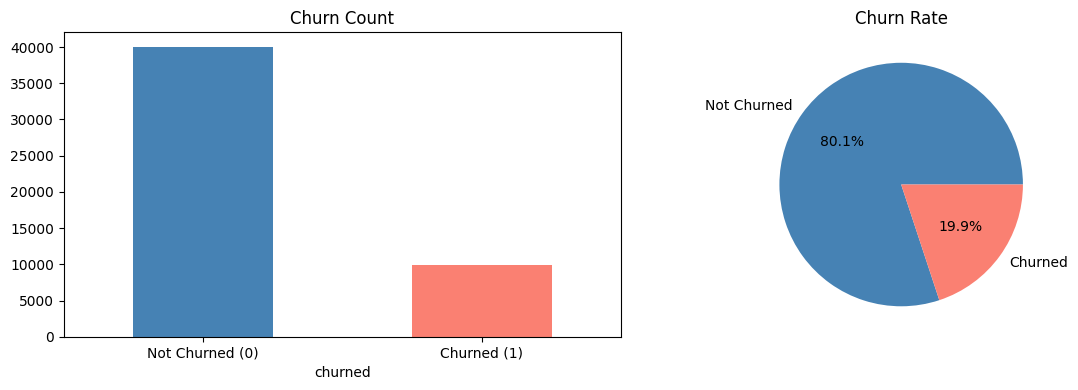

In [90]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['churned'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Churn Count')
axes[0].set_xticklabels(['Not Churned (0)', 'Churned (1)'], rotation=0)

df['churned'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
    labels=['Not Churned', 'Churned'], autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Churn Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

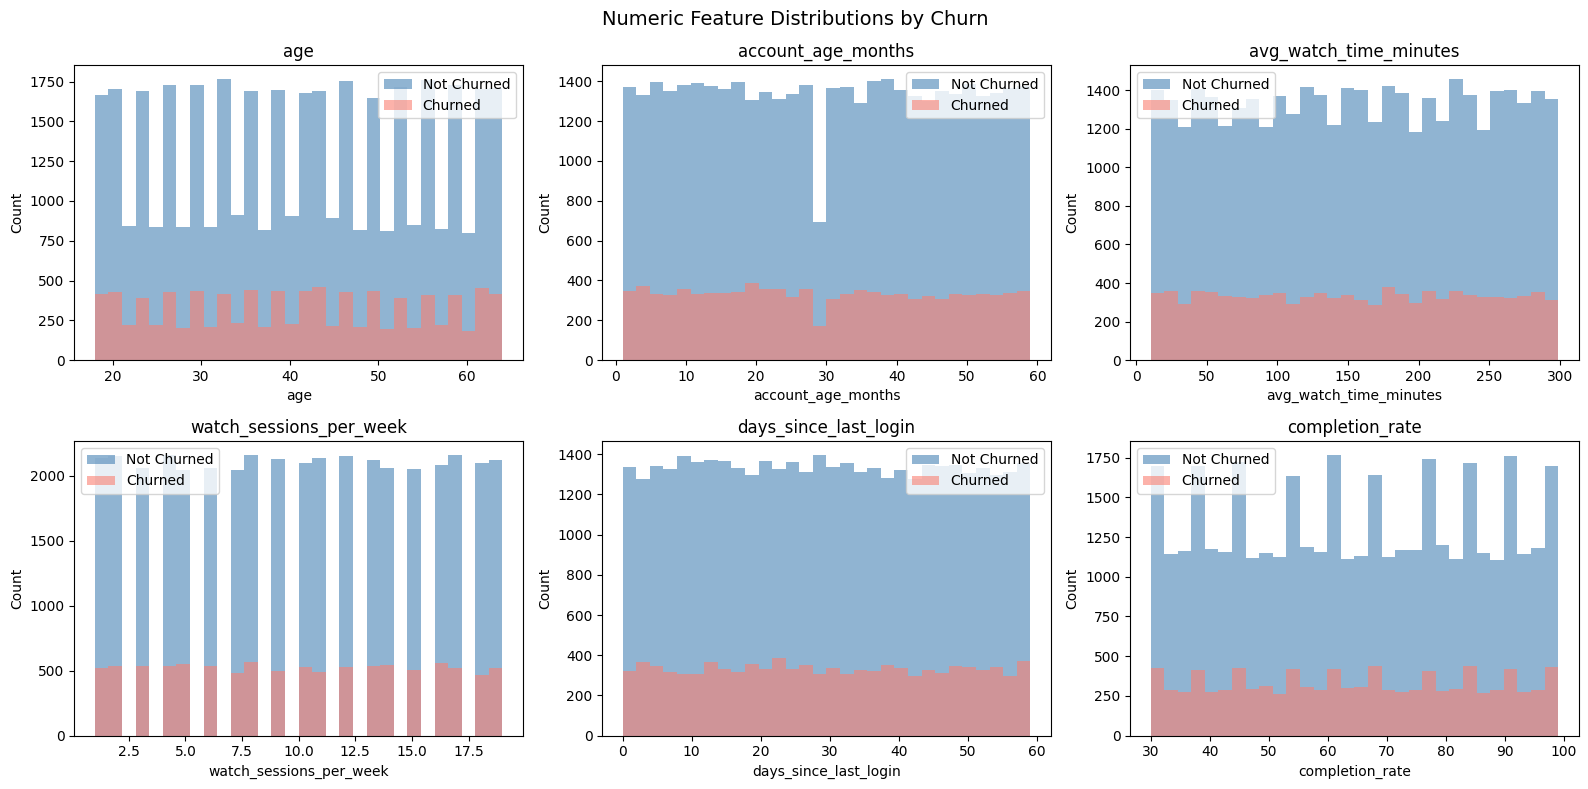

In [91]:
# Numeric feature distributions by churn
numeric_cols = ['age', 'account_age_months', 'avg_watch_time_minutes',
                'watch_sessions_per_week', 'days_since_last_login', 'completion_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[df['churned']=='No'][col], bins=30, alpha=0.6, label='Not Churned', color='steelblue')
    ax.hist(df[df['churned']=='Yes'][col], bins=30, alpha=0.6, label='Churned', color='salmon')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Numeric Feature Distributions by Churn', fontsize=14)
plt.tight_layout()
plt.show()

## Data Preprocessing

We can drop the user id column, and also perform label encoding on the categorical fields.

In [92]:
# Check before encoding
print("Before:", df['churned'].unique())

# Only encode if still strings
if df['churned'].dtype == object:
    df['churned'] = (df['churned'] == 'Yes').astype(int)

print("After:", df['churned'].value_counts())

Before: ['No' 'Yes']
After: churned
0    40036
1     9964
Name: count, dtype: int64


In [93]:
# Drop user_id — arbitrary identifier, not predictive
df.drop(columns=['user_id'], inplace=True)

# Label-encode all object columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('\nEncoded dtypes:')
print(df.dtypes)
df.head()

Categorical columns to encode: ['gender', 'country', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre']

Encoded dtypes:
age                            int64
gender                         int64
country                        int64
account_age_months             int64
subscription_type              int64
monthly_fee                  float64
payment_method                 int64
primary_device                 int64
devices_used                   int64
favorite_genre                 int64
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                        int64
dtype: object


,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,56,1,5,17,2,15.99,2,0,1,6,220,17,3,60,1.7,5,66,16,0
1,46,0,9,20,2,12.99,2,3,2,2,76,15,4,71,4.6,7,78,14,0
2,32,2,9,25,0,15.99,2,3,2,1,215,6,13,33,2.0,27,29,41,0
3,60,1,2,37,2,12.99,2,2,3,0,280,4,9,58,1.2,9,23,22,0
4,25,1,1,23,1,12.99,2,1,3,4,261,15,9,64,1.3,49,56,54,0


## Model Setup

Next, split the dataset into feature vectors `X` and target vector (churned) `Y` to fit a [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). You will then compare the performance of each feature selection technique, using [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [roc](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score), [precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score), [recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score) and [f1-score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score) as evaluation metrics.

In [94]:
# Feature / target split

#df['churned'] = (df['churned'] == 'Yes').astype(int)

X = df.drop('churned', axis=1)
Y = df['churned']

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape:  {Y.shape}')

Feature matrix shape: (50000, 18)
Target vector shape:  (50000,)


In [95]:
def fit_model(X_train, Y_train):
    model = RandomForestClassifier(
        criterion='entropy',
        n_estimators=100,
        class_weight='balanced',   # <-- add this
        random_state=47
    )
    model.fit(X_train, Y_train)
    return model


def calculate_metrics(model, X_test, Y_test):
    """Return accuracy, ROC-AUC, precision, recall and F1."""
    y_pred = model.predict(X_test)
    return (
        accuracy_score(Y_test, y_pred),
        roc_auc_score(Y_test, y_pred),
        precision_score(Y_test, y_pred, zero_division=0),
        recall_score(Y_test, y_pred, zero_division=0),
        f1_score(Y_test, y_pred, zero_division=0)
    )


def train_and_get_metrics(X_feat, Y):
    """Split, scale, train and return metrics."""
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_feat, Y, test_size=0.2, stratify=Y, random_state=123)
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)
    model = fit_model(X_train_s, Y_train)
    return calculate_metrics(model, X_test_s, Y_test)


def evaluate_model_on_features(X_feat, Y):
    """Return a one-row DataFrame of evaluation metrics."""
    acc, roc, prec, rec, f1 = train_and_get_metrics(X_feat, Y)
    return pd.DataFrame(
        [[acc, roc, prec, rec, f1, X_feat.shape[1]]],
        columns=['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1 Score', 'Feature Count']
    )

In [96]:
print("Y dtype:", Y.dtype)
print("Y unique:", Y.unique())
print("Y value counts:\n", Y.value_counts())

Y dtype: int64
Y unique: [0 1]
Y value counts:
 churned
0    40036
1     9964
Name: count, dtype: int64


In [97]:
# Baseline — all features
baseline_df = evaluate_model_on_features(X, Y)
baseline_df.index = ['All Features']

results = baseline_df.copy()
results

,Accuracy,ROC-AUC,Precision,Recall,F1 Score,Feature Count
All Features,0.8007,0.5,0.0,0.0,0.0,18


## Correlation Matrix

It is a good idea to calculate and visualize the correlation matrix of a data frame to see which features have high correlation. You can do that with just a few lines as shown below. The Pandas [corr()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) method computes the Pearson correlation by default and you will plot it with Matlab PyPlot and Seaborn. The darker blue boxes show features with high positive correlation while white ones indicate high negative correlation. The diagonals will have 1's because the feature is mapped on to itself.

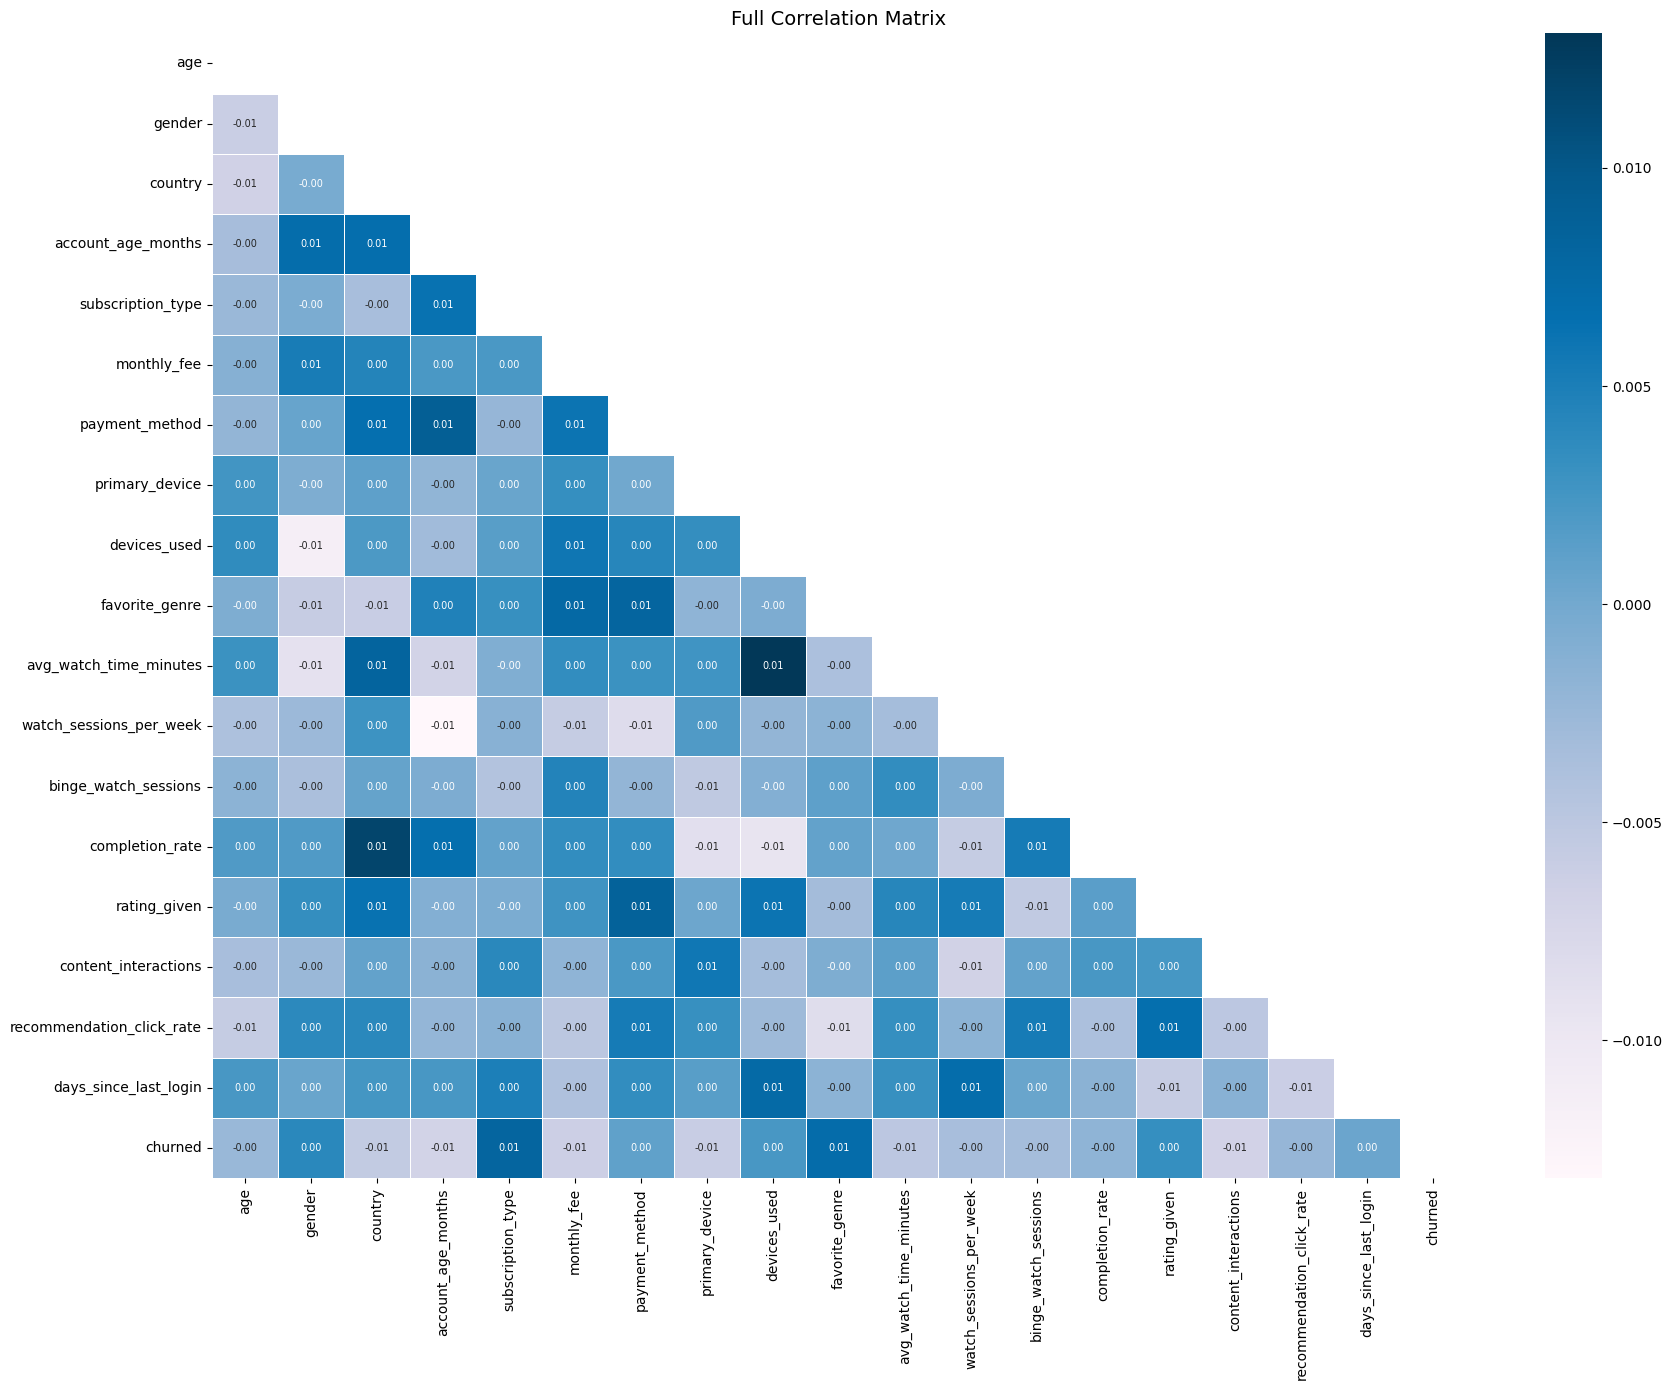

In [98]:
plt.figure(figsize=(18, 14))
cor = df.corr()
mask = np.triu(np.ones_like(cor, dtype=bool))   # upper triangle mask
sns.heatmap(cor, annot=True, fmt='.2f', cmap='PuBu',
            mask=mask, linewidths=0.5, annot_kws={'size': 7})
plt.title('Full Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

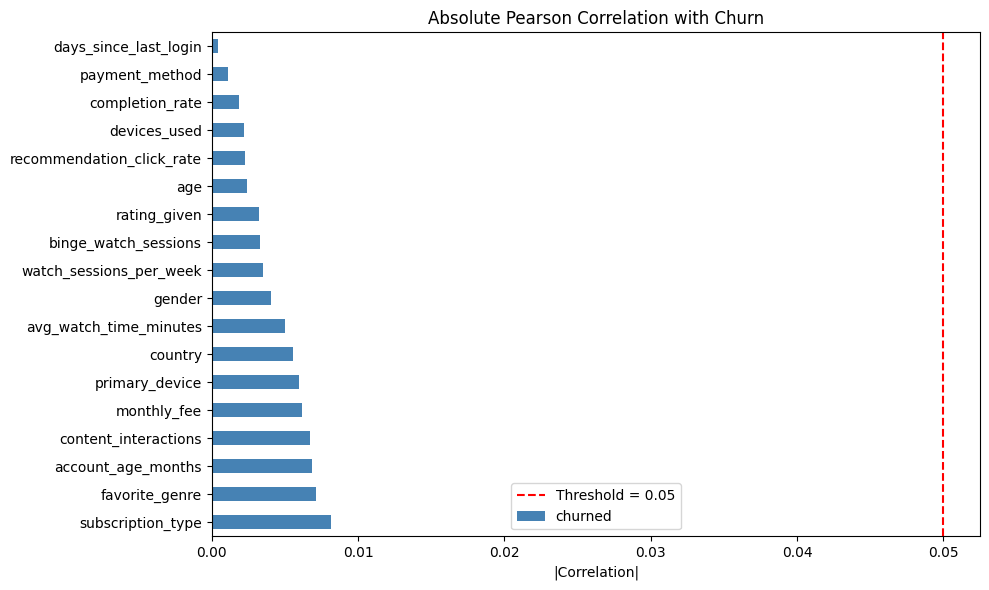

subscription_type            0.008164
favorite_genre               0.007114
account_age_months           0.006852
content_interactions         0.006720
monthly_fee                  0.006194
primary_device               0.005943
country                      0.005560
avg_watch_time_minutes       0.005022
gender                       0.004040
watch_sessions_per_week      0.003505
binge_watch_sessions         0.003292
rating_given                 0.003255
age                          0.002417
recommendation_click_rate    0.002262
devices_used                 0.002238
completion_rate              0.001839
payment_method               0.001085
days_since_last_login        0.000453
Name: churned, dtype: float64


In [99]:
# Correlation of each feature with the target (churned)
cor_target = abs(cor['churned']).drop('churned').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
cor_target.plot(kind='barh', color='steelblue')
plt.axvline(x=0.05, color='red', linestyle='--', label='Threshold = 0.05')
plt.title('Absolute Pearson Correlation with Churn')
plt.xlabel('|Correlation|')
plt.legend()
plt.tight_layout()
plt.show()

print(cor_target)